## 1. Environment Setup & Imports

In [1]:
!pip install faiss-cpu sentence-transformers rank-bm25 scikit-learn matplotlib seaborn pandas numpy tqdm --quiet


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import os
import time
import warnings
from pathlib import Path

import faiss
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860", "#DA8BC3", "#8C8C8C", "#CCB974"]
plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.titlesize": 12, "axes.labelsize": 10})

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

D:\IIT\Degree - AI and Data Science\2nd Year - 1st Sem\DSGP\call-center-automation\rag-multi-agent\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


## 2. Load All Inputs

In [3]:
with open(OUTPUT_DIR / "chunks_fixed.json", "r", encoding="utf-8") as f:
    chunks_fixed = json.load(f)
with open(OUTPUT_DIR / "chunks_sentence.json", "r", encoding="utf-8") as f:
    chunks_sentence = json.load(f)
with open(OUTPUT_DIR / "chunks_processed.json", "r", encoding="utf-8") as f:
    chunks_semantic = json.load(f)

with open(OUTPUT_DIR / "qa_test_set.json", "r", encoding="utf-8") as f:
    qa_test_set = json.load(f)

with open(OUTPUT_DIR / "rag_results.json", "r", encoding="utf-8") as f:
    rag_results = json.load(f)

CHUNK_SETS = {
    "Fixed\n(24 chunks, ~133w)": chunks_fixed,
    "Sentence\n(91 chunks, ~40w)": chunks_sentence,
    "Semantic\n(7 chunks, ~403w)": chunks_semantic,
}

for name, chunks in CHUNK_SETS.items():
    wcs = [c["word_count"] for c in chunks]
    print(f"{name.replace(chr(10), ' '):30s}: {len(chunks):3d} chunks | "
          f"avg={sum(wcs) / len(wcs):.0f}w | min={min(wcs)}w | max={max(wcs)}w")
print(f"\nQA test set: {len(qa_test_set)} questions")

Fixed (24 chunks, ~133w)      :  24 chunks | avg=133w | min=50w | max=150w
Sentence (91 chunks, ~40w)    :  91 chunks | avg=40w | min=11w | max=81w
Semantic (7 chunks, ~403w)    :   7 chunks | avg=403w | min=18w | max=1017w

QA test set: 30 questions


## 3. Evaluation Metrics

In [4]:
def precision_at_k(retrieved, relevant, k):
    top_k = [r for r in retrieved[:k] if r >= 0]
    return len(set(top_k) & set(relevant)) / len(top_k) if top_k else 0.0


def recall_at_k(retrieved, relevant, k):
    if not relevant:
        return 0.0
    top_k = [r for r in retrieved[:k] if r >= 0]
    return len(set(top_k) & set(relevant)) / len(relevant)


def hit_at_k(retrieved, relevant, k):
    top_k = [r for r in retrieved[:k] if r >= 0]
    return int(bool(set(top_k) & set(relevant)))


def reciprocal_rank(retrieved, relevant):
    for rank, idx in enumerate(retrieved, start=1):
        if idx in relevant:
            return 1.0 / rank
    return 0.0


def evaluate_retrieval(qa_set, retrieve_fn, label):
    rows = []
    for qa in qa_set:
        relevant = qa["relevant_chunk_indices"]
        t0 = time.perf_counter()
        retrieved = retrieve_fn(qa["question"], k=5)
        latency = (time.perf_counter() - t0) * 1000
        rows.append({
            "q_id": qa["q_id"],
            "q_type": qa["q_type"],
            "Hit@1": hit_at_k(retrieved, relevant, 1),
            "Hit@3": hit_at_k(retrieved, relevant, 3),
            "Hit@5": hit_at_k(retrieved, relevant, 5),
            "P@1": precision_at_k(retrieved, relevant, 1),
            "P@3": precision_at_k(retrieved, relevant, 3),
            "R@3": recall_at_k(retrieved, relevant, 3),
            "MRR": reciprocal_rank(retrieved, relevant),
            "latency_ms": round(latency, 3),
        })
    df = pd.DataFrame(rows)
    summary = {
        "config": label,
        "Hit@1": round(df["Hit@1"].mean(), 4),
        "Hit@3": round(df["Hit@3"].mean(), 4),
        "Hit@5": round(df["Hit@5"].mean(), 4),
        "P@1": round(df["P@1"].mean(), 4),
        "P@3": round(df["P@3"].mean(), 4),
        "R@3": round(df["R@3"].mean(), 4),
        "MRR": round(df["MRR"].mean(), 4),
        "avg_latency_ms": round(df["latency_ms"].mean(), 3),
    }
    return df, summary

## 4. Retriever Builders

In [5]:
def build_tfidf(chunks):
    texts = [c["text"] for c in chunks]
    vec = TfidfVectorizer(max_features=500, ngram_range=(1, 2),
                          sublinear_tf=True, min_df=1)
    matrix = vec.fit_transform(texts)

    def retrieve(query, k=5):
        q_vec = vec.transform([query])
        scores = cosine_similarity(q_vec, matrix).flatten()
        return scores.argsort()[::-1][:k].tolist()

    return retrieve


def build_bm25(chunks):
    tokenized = [c["text"].lower().split() for c in chunks]
    bm25 = BM25Okapi(tokenized)

    def retrieve(query, k=5):
        scores = bm25.get_scores(query.lower().split())
        return np.argsort(scores)[::-1][:k].tolist()

    return retrieve


try:
    embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
except Exception:
    cache_dir = os.path.expanduser("~/.cache/huggingface/hub")
    local_path = None
    if os.path.exists(cache_dir):
        for d in os.listdir(cache_dir):
            if "MiniLM" in d:
                snap_dir = os.path.join(cache_dir, d, "snapshots")
                if os.path.exists(snap_dir):
                    snaps = os.listdir(snap_dir)
                    if snaps:
                        local_path = os.path.join(snap_dir, snaps[0])
                        break
    embed_model = SentenceTransformer(local_path)


def build_dense(chunks):
    if "embedding" in chunks[0]:
        emb_matrix = np.array([c["embedding"] for c in chunks], dtype=np.float32)
    else:
        texts = [c["text"] for c in chunks]
        emb_matrix = embed_model.encode(texts, normalize_embeddings=True,
                                        show_progress_bar=True, batch_size=32)
        emb_matrix = emb_matrix.astype(np.float32)
    dim = emb_matrix.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(emb_matrix)

    def retrieve(query, k=5):
        q_vec = embed_model.encode([query], normalize_embeddings=True,
                                   show_progress_bar=False).astype(np.float32)
        _, indices = index.search(q_vec, k)
        return indices[0].tolist()

    return retrieve

No sentence-transformers model found with name C:\Users\USER/.cache/huggingface/hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2\snapshots\c5ee24cb16019beea0893ab7796b1df96625c6b8. Creating a new one with mean pooling.


## 5. Run the Full 3 x 3 Ablation Grid

In [6]:
RETRIEVER_BUILDERS = {
    "TF-IDF": build_tfidf,
    "BM25": build_bm25,
    "Dense": build_dense,
}

CHUNK_SHORT = {
    "Fixed\n(24 chunks, ~133w)": "Fixed",
    "Sentence\n(91 chunks, ~40w)": "Sentence",
    "Semantic\n(7 chunks, ~403w)": "Semantic",
}

all_summaries = []
all_per_q = {}

for chunk_label, chunks in CHUNK_SETS.items():
    short_chunk = CHUNK_SHORT[chunk_label]
    for ret_label, builder in RETRIEVER_BUILDERS.items():
        config_label = f"{short_chunk} + {ret_label}"
        print(f"Config: {config_label}")
        print(f"Chunks: {len(chunks)} | Retriever: {ret_label}")

        retrieve_fn = builder(chunks)
        df, summary = evaluate_retrieval(qa_test_set, retrieve_fn, config_label)

        summary["chunk_strategy"] = short_chunk
        summary["retriever"] = ret_label
        summary["n_chunks"] = len(chunks)
        all_summaries.append(summary)
        all_per_q[config_label] = df.to_dict(orient="records")

        print(f"  Hit@1={summary['Hit@1']:.3f}  Hit@3={summary['Hit@3']:.3f}  "
              f"MRR={summary['MRR']:.3f}  latency={summary['avg_latency_ms']:.2f}ms")

df_results = pd.DataFrame(all_summaries)
print(df_results[["config", "Hit@1", "Hit@3", "MRR", "avg_latency_ms"]].to_string(index=False))

Config: Fixed + TF-IDF
Chunks: 24 | Retriever: TF-IDF
  Hit@1=0.033  Hit@3=0.033  MRR=0.048  latency=1.42ms
Config: Fixed + BM25
Chunks: 24 | Retriever: BM25
  Hit@1=0.000  Hit@3=0.000  MRR=0.032  latency=0.16ms
Config: Fixed + Dense
Chunks: 24 | Retriever: Dense


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

  Hit@1=0.500  Hit@3=0.500  MRR=0.522  latency=8.96ms
Config: Sentence + TF-IDF
Chunks: 91 | Retriever: TF-IDF
  Hit@1=0.000  Hit@3=0.000  MRR=0.000  latency=0.61ms
Config: Sentence + BM25
Chunks: 91 | Retriever: BM25
  Hit@1=0.000  Hit@3=0.000  MRR=0.000  latency=0.32ms
Config: Sentence + Dense
Chunks: 91 | Retriever: Dense


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  Hit@1=0.000  Hit@3=0.000  MRR=0.000  latency=9.67ms
Config: Semantic + TF-IDF
Chunks: 7 | Retriever: TF-IDF
  Hit@1=0.733  Hit@3=1.000  MRR=0.839  latency=0.54ms
Config: Semantic + BM25
Chunks: 7 | Retriever: BM25
  Hit@1=0.567  Hit@3=0.967  MRR=0.753  latency=0.12ms
Config: Semantic + Dense
Chunks: 7 | Retriever: Dense
  Hit@1=0.200  Hit@3=0.667  MRR=0.486  latency=10.63ms
           config  Hit@1  Hit@3    MRR  avg_latency_ms
   Fixed + TF-IDF 0.0333 0.0333 0.0483           1.417
     Fixed + BM25 0.0000 0.0000 0.0317           0.158
    Fixed + Dense 0.5000 0.5000 0.5217           8.960
Sentence + TF-IDF 0.0000 0.0000 0.0000           0.606
  Sentence + BM25 0.0000 0.0000 0.0000           0.322
 Sentence + Dense 0.0000 0.0000 0.0000           9.672
Semantic + TF-IDF 0.7333 1.0000 0.8389           0.544
  Semantic + BM25 0.5667 0.9667 0.7528           0.117
 Semantic + Dense 0.2000 0.6667 0.4861          10.634


## 6. Hit@1 Heatmap: Chunking x Retriever

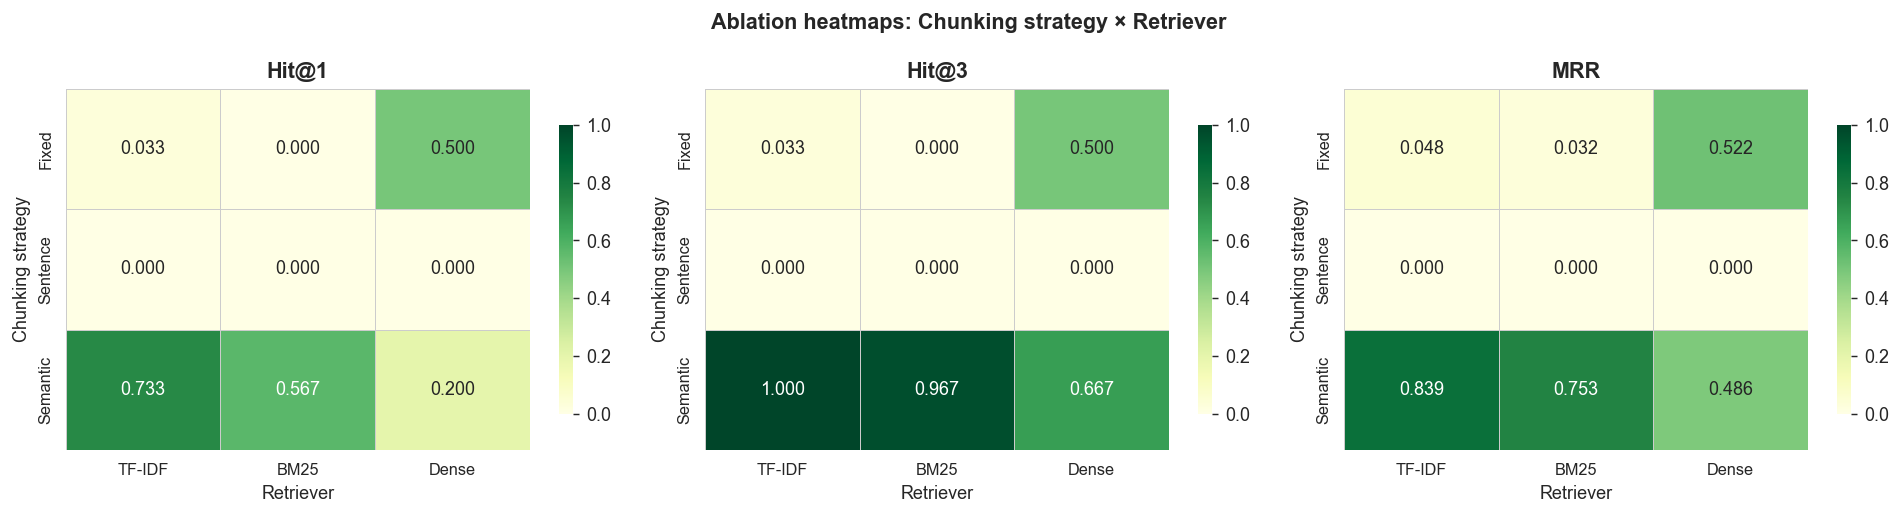

Saved: 28_ablation_heatmaps.png


In [7]:
chunk_strategies = ["Fixed", "Sentence", "Semantic"]
retrievers = ["TF-IDF", "BM25", "Dense"]


def make_matrix(metric):
    mat = np.zeros((len(chunk_strategies), len(retrievers)))
    for row in all_summaries:
        i = chunk_strategies.index(row["chunk_strategy"])
        j = retrievers.index(row["retriever"])
        mat[i, j] = row[metric]
    return mat


hit1_mat = make_matrix("Hit@1")
hit3_mat = make_matrix("Hit@3")
mrr_mat = make_matrix("MRR")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Ablation heatmaps: Chunking strategy × Retriever",
             fontweight="bold")

for ax, mat, title in [
    (axes[0], hit1_mat, "Hit@1"),
    (axes[1], hit3_mat, "Hit@3"),
    (axes[2], mrr_mat, "MRR"),
]:
    sns.heatmap(mat, annot=True, fmt=".3f", cmap="YlGn",
                xticklabels=retrievers,
                yticklabels=chunk_strategies,
                vmin=0, vmax=1, ax=ax,
                linewidths=0.5, linecolor="#cccccc",
                cbar_kws={"shrink": 0.8})
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Retriever")
    ax.set_ylabel("Chunking strategy")
    ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "28_ablation_heatmaps.png", bbox_inches="tight")
plt.show()
print("Saved: 28_ablation_heatmaps.png")

## 7. Chunking Strategy Effect (averaged over retrievers)

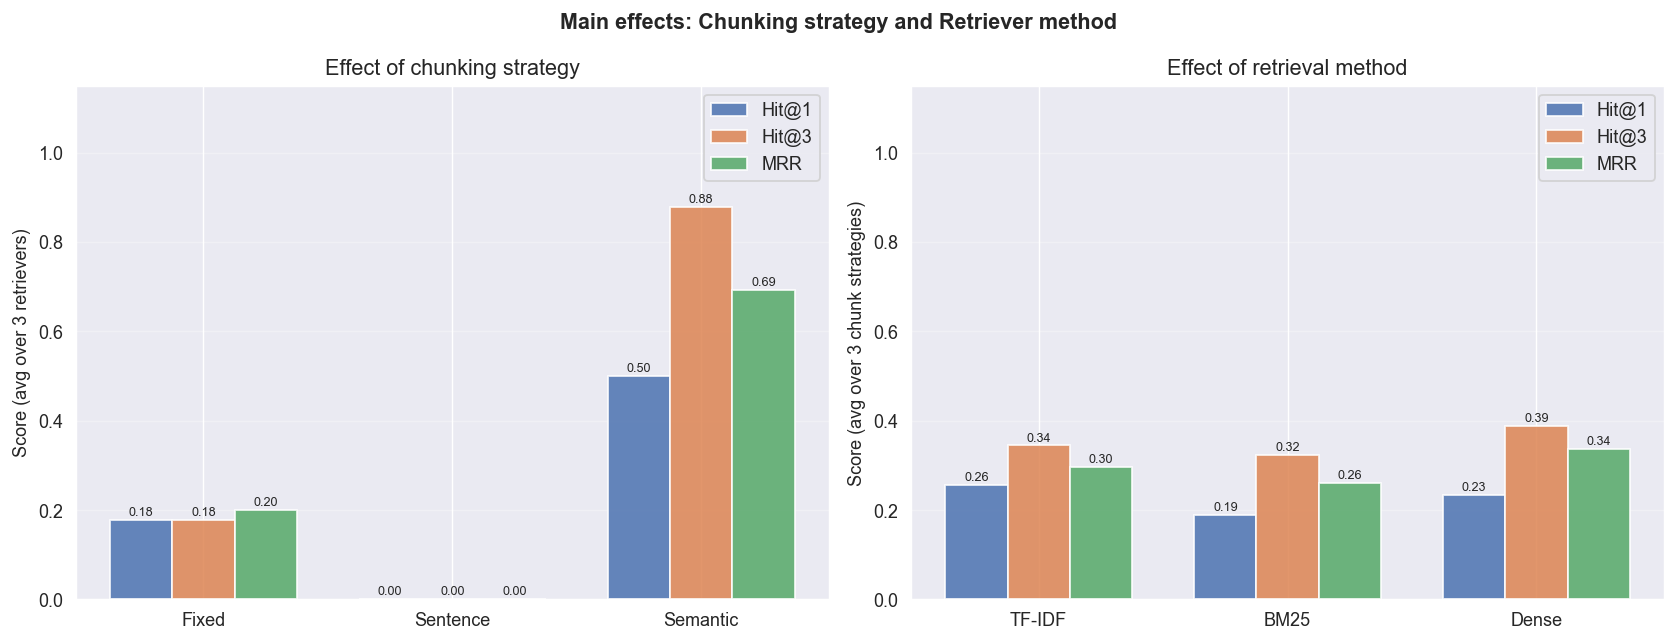

Saved: 29_main_effects.png


In [8]:
df_chunk_avg = df_results.groupby("chunk_strategy")[["Hit@1", "Hit@3", "MRR"]].mean().reindex(chunk_strategies)
df_ret_avg = df_results.groupby("retriever")[["Hit@1", "Hit@3", "MRR"]].mean().reindex(retrievers)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Main effects: Chunking strategy and Retriever method",
             fontweight="bold")

ax = axes[0]
x = np.arange(len(chunk_strategies))
w = 0.25
for i, (metric, color) in enumerate(zip(["Hit@1", "Hit@3", "MRR"], PALETTE)):
    bars = ax.bar(x + i * w, df_chunk_avg[metric], w, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, df_chunk_avg[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", fontsize=7)
ax.set_xticks(x + w)
ax.set_xticklabels(chunk_strategies)
ax.set_ylabel("Score (avg over 3 retrievers)")
ax.set_title("Effect of chunking strategy")
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
x2 = np.arange(len(retrievers))
for i, (metric, color) in enumerate(zip(["Hit@1", "Hit@3", "MRR"], PALETTE)):
    bars = ax2.bar(x2 + i * w, df_ret_avg[metric], w, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, df_ret_avg[metric]):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", fontsize=7)
ax2.set_xticks(x2 + w)
ax2.set_xticklabels(retrievers)
ax2.set_ylabel("Score (avg over 3 chunk strategies)")
ax2.set_title("Effect of retrieval method")
ax2.set_ylim(0, 1.15)
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "29_main_effects.png", bbox_inches="tight")
plt.show()
print("Saved: 29_main_effects.png")

## 8. All 9 Configs Ranked by MRR

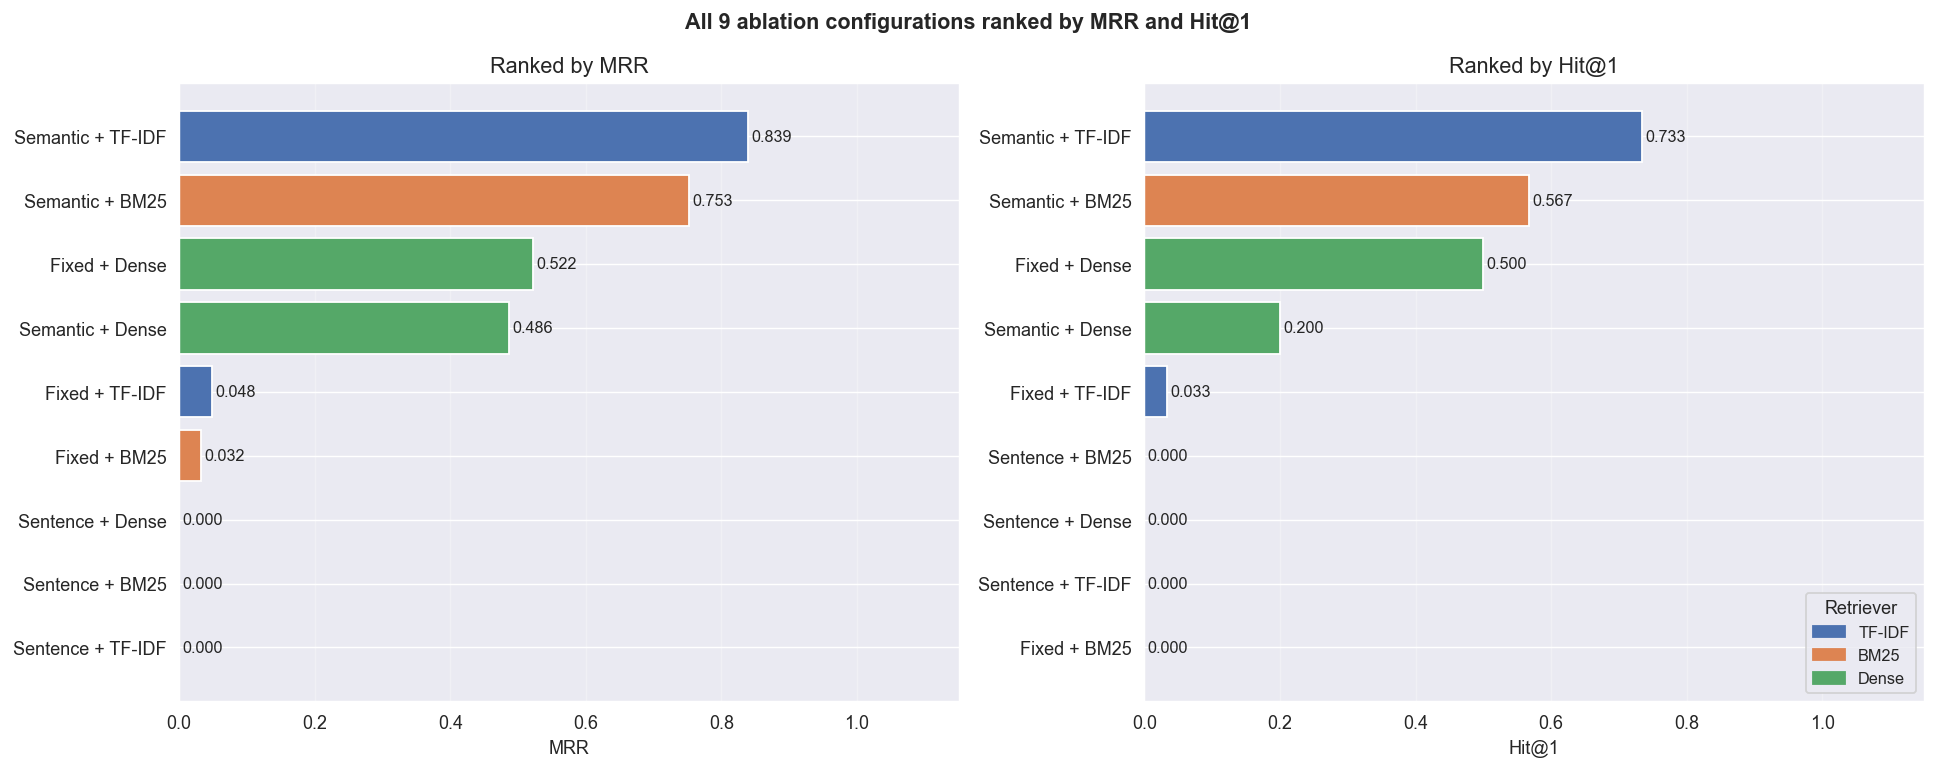

Saved: 30_configs_ranked.png


In [9]:
df_ranked = df_results.sort_values("MRR", ascending=True).copy()

ret_color_map = {"TF-IDF": PALETTE[0], "BM25": PALETTE[1], "Dense": PALETTE[2]}
bar_colors = [ret_color_map[r] for r in df_ranked["retriever"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("All 9 ablation configurations ranked by MRR and Hit@1",
             fontweight="bold")

for ax, metric in zip(axes, ["MRR", "Hit@1"]):
    df_m = df_results.sort_values(metric, ascending=True)
    bar_colors_m = [ret_color_map[r] for r in df_m["retriever"]]
    bars = ax.barh(df_m["config"], df_m[metric], color=bar_colors_m, edgecolor="white")
    for bar, val in zip(bars, df_m[metric]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.set_xlabel(metric)
    ax.set_title(f"Ranked by {metric}")
    ax.set_xlim(0, 1.15)
    ax.grid(axis="x", alpha=0.3)

legend_patches = [mpatches.Patch(color=c, label=r)
                  for r, c in ret_color_map.items()]
axes[1].legend(handles=legend_patches, title="Retriever",
               loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "30_configs_ranked.png", bbox_inches="tight")
plt.show()
print("Saved: 30_configs_ranked.png")

## 9. Dense Retrieval Deep-Dive

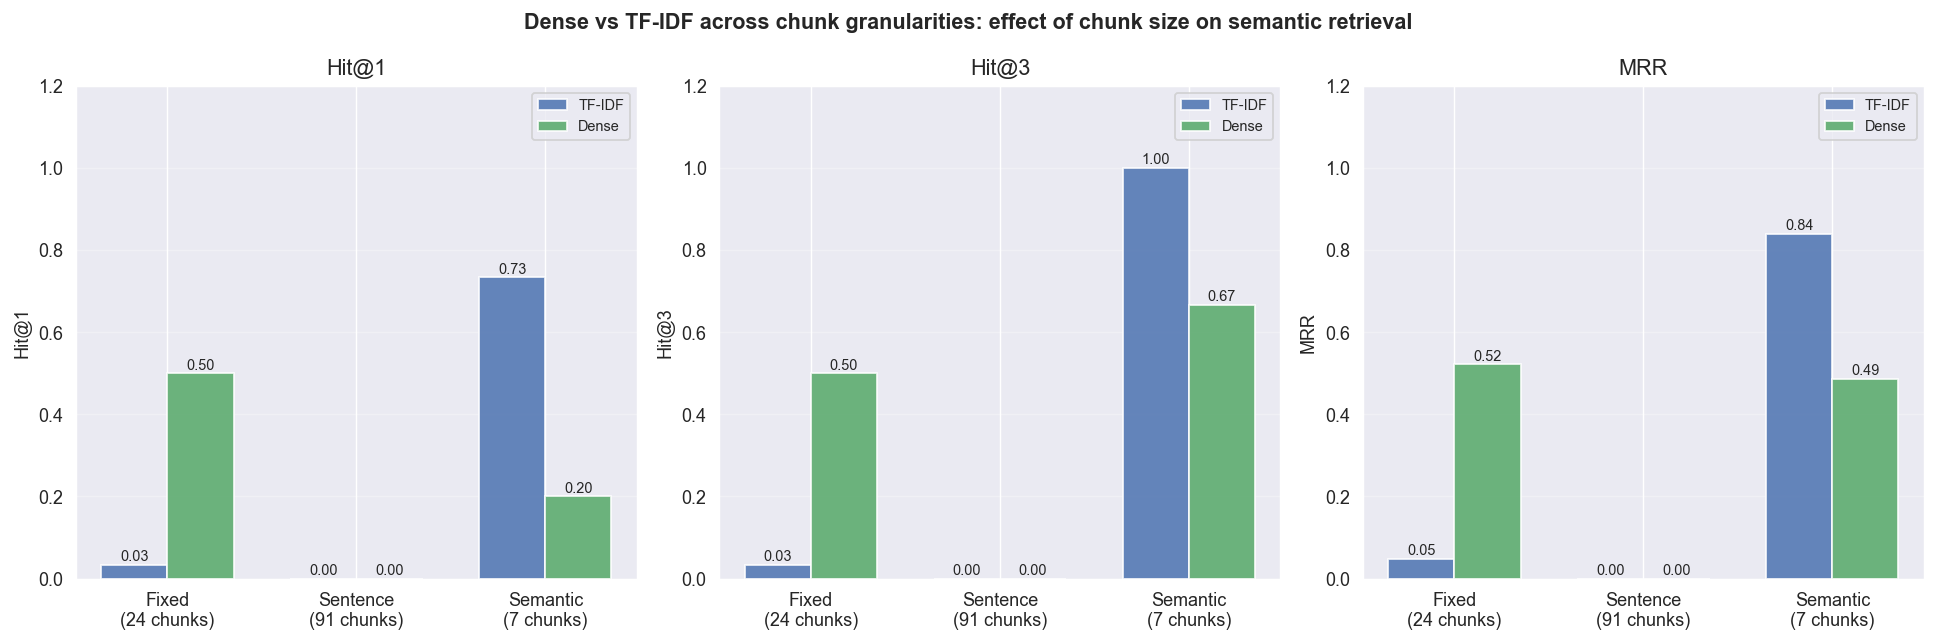

Saved: 31_dense_vs_tfidf_by_chunk.png


In [10]:
dense_rows = [r for r in all_summaries if r["retriever"] == "Dense"]
tfidf_rows = [r for r in all_summaries if r["retriever"] == "TF-IDF"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Dense vs TF-IDF across chunk granularities: "
             "effect of chunk size on semantic retrieval",
             fontweight="bold")

n_chunks_map = {"Fixed": 24, "Sentence": 91, "Semantic": 7}

for ax, metric in zip(axes, ["Hit@1", "Hit@3", "MRR"]):
    x = np.arange(3)
    w = 0.35
    d_vals = [next(r[metric] for r in dense_rows if r["chunk_strategy"] == s)
              for s in chunk_strategies]
    t_vals = [next(r[metric] for r in tfidf_rows if r["chunk_strategy"] == s)
              for s in chunk_strategies]

    b1 = ax.bar(x - w / 2, t_vals, w, label="TF-IDF", color=PALETTE[0], alpha=0.85)
    b2 = ax.bar(x + w / 2, d_vals, w, label="Dense", color=PALETTE[2], alpha=0.85)
    for bar, val in list(zip(b1, t_vals)) + list(zip(b2, d_vals)):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([
        f"{s}\n({n_chunks_map[s]} chunks)" for s in chunk_strategies
    ])
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_ylim(0, 1.2)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "31_dense_vs_tfidf_by_chunk.png", bbox_inches="tight")
plt.show()
print("Saved: 31_dense_vs_tfidf_by_chunk.png")

## 10. Per-Question-Type Breakdown

Best TF-IDF   config: Semantic + TF-IDF              | MRR=0.839
Best BM25     config: Semantic + BM25                | MRR=0.753
Best Dense    config: Fixed + Dense                  | MRR=0.522


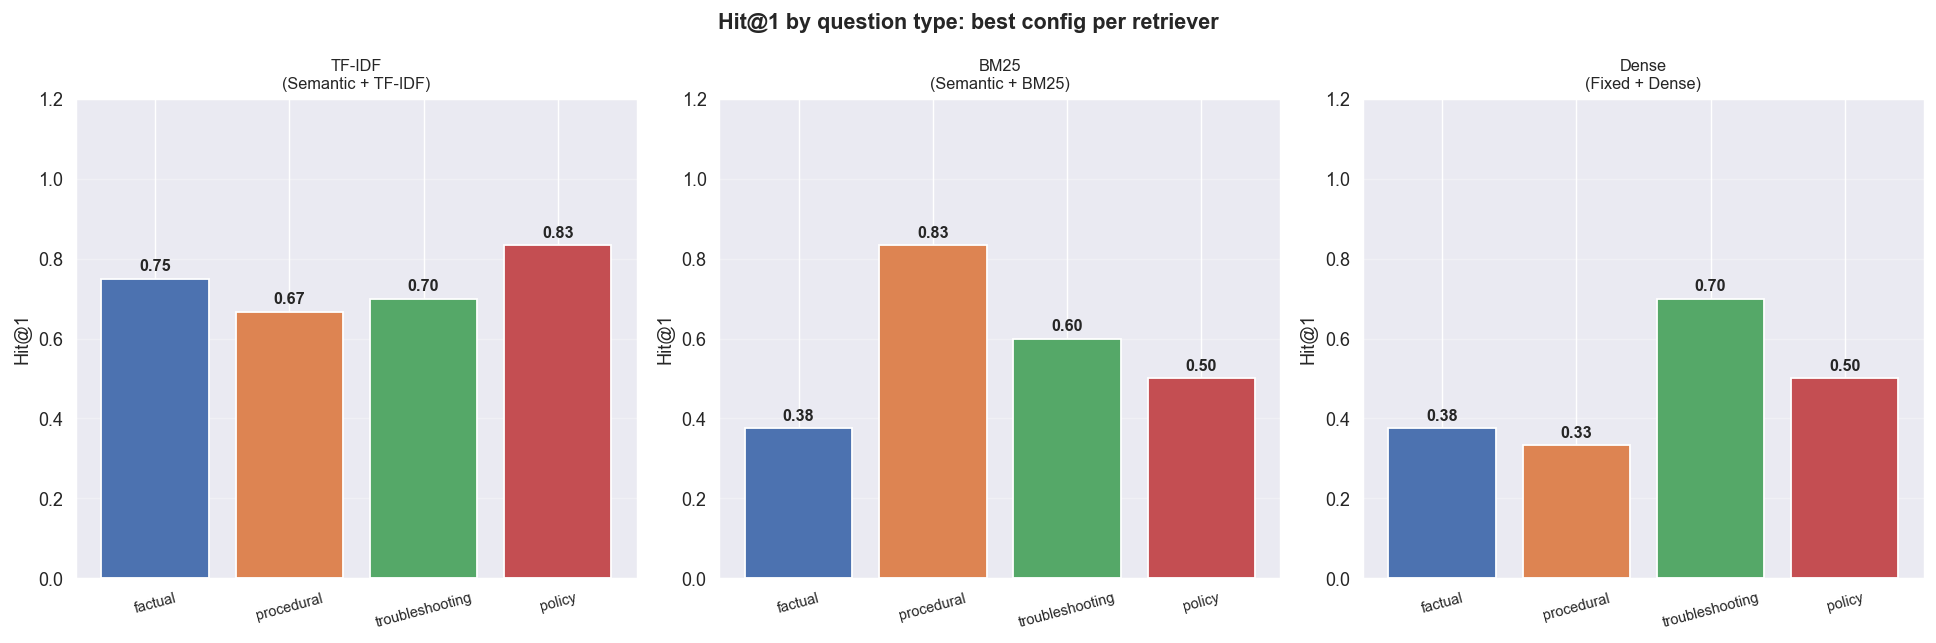

Saved: 32_by_question_type.png


In [11]:
best_configs = {}
for ret in retrievers:
    best_row = max(
        [r for r in all_summaries if r["retriever"] == ret],
        key=lambda r: r["MRR"]
    )
    best_configs[ret] = best_row["config"]
    print(f"Best {ret:8s} config: {best_row['config']:30s} | MRR={best_row['MRR']:.3f}")

q_types = ["factual", "procedural", "troubleshooting", "policy"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Hit@1 by question type: best config per retriever",
             fontweight="bold")

for ax, (ret, config) in zip(axes, best_configs.items()):
    df_pq = pd.DataFrame(all_per_q[config])
    type_hit1 = df_pq.groupby("q_type")["Hit@1"].mean().reindex(q_types, fill_value=0)
    bars = ax.bar(q_types, type_hit1.values, color=PALETTE[:4], edgecolor="white")
    for bar, val in zip(bars, type_hit1.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(f"{ret}\n({config})", fontsize=9)
    ax.set_ylabel("Hit@1")
    ax.set_ylim(0, 1.2)
    ax.set_xticklabels(q_types, rotation=15, fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "32_by_question_type.png", bbox_inches="tight")
plt.show()
print("Saved: 32_by_question_type.png")

## 11. Final Ablation Summary Table

 Rank            config chunk_strategy retriever  n_chunks  Hit@1  Hit@3    MRR  avg_latency_ms  ΔMRR vs NB4
    1 Semantic + TF-IDF       Semantic    TF-IDF         7 0.7333 1.0000 0.8389           0.544       0.3528
    2   Semantic + BM25       Semantic      BM25         7 0.5667 0.9667 0.7528           0.117       0.2667
    3     Fixed + Dense          Fixed     Dense        24 0.5000 0.5000 0.5217           8.960       0.0356
    4  Semantic + Dense       Semantic     Dense         7 0.2000 0.6667 0.4861          10.634       0.0000
    5    Fixed + TF-IDF          Fixed    TF-IDF        24 0.0333 0.0333 0.0483           1.417      -0.4378
    6      Fixed + BM25          Fixed      BM25        24 0.0000 0.0000 0.0317           0.158      -0.4544
    7 Sentence + TF-IDF       Sentence    TF-IDF        91 0.0000 0.0000 0.0000           0.606      -0.4861
    8   Sentence + BM25       Sentence      BM25        91 0.0000 0.0000 0.0000           0.322      -0.4861
    9  Sentence + D

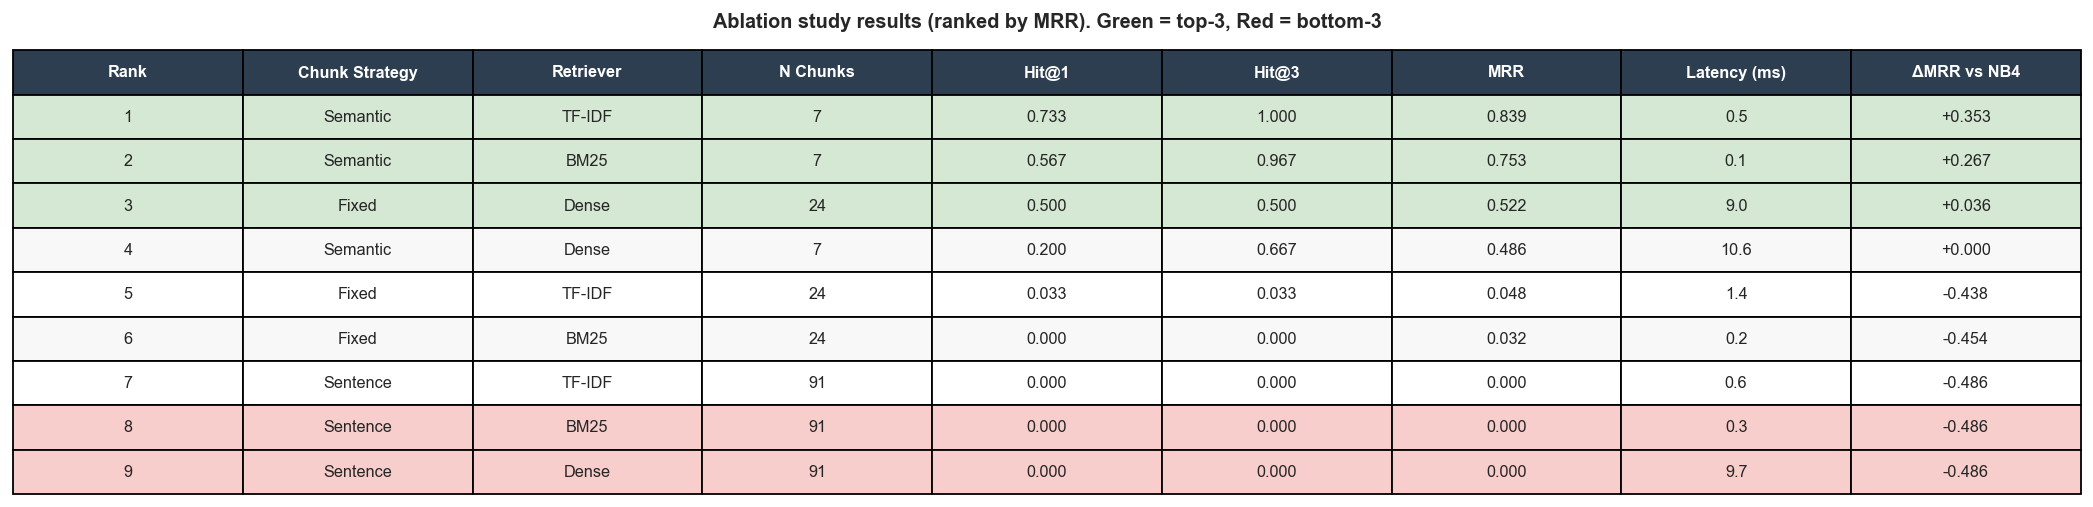

Saved: 33_ablation_table.png


In [12]:
df_table = df_results[["config", "chunk_strategy", "retriever", "n_chunks",
                       "Hit@1", "Hit@3", "MRR", "avg_latency_ms"]].copy()
df_table = df_table.sort_values("MRR", ascending=False).reset_index(drop=True)
df_table.insert(0, "Rank", range(1, len(df_table) + 1))

nb4_hit1 = rag_results["retrieval"]["summary"]["Hit@1"]
nb4_mrr = rag_results["retrieval"]["summary"]["MRR"]
df_table["ΔMRR vs NB4"] = (df_table["MRR"] - nb4_mrr).round(4)

print(df_table.to_string(index=False))

display_cols = ["Rank", "Chunk Strategy", "Retriever", "N Chunks",
                "Hit@1", "Hit@3", "MRR", "Latency (ms)", "ΔMRR vs NB4"]
cell_data = []
for _, row in df_table.iterrows():
    cell_data.append([
        int(row["Rank"]),
        row["chunk_strategy"],
        row["retriever"],
        int(row["n_chunks"]),
        f"{row['Hit@1']:.3f}",
        f"{row['Hit@3']:.3f}",
        f"{row['MRR']:.3f}",
        f"{row['avg_latency_ms']:.1f}",
        f"{row['ΔMRR vs NB4']:+.3f}",
    ])

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")
table = ax.table(
    cellText=cell_data, colLabels=display_cols,
    cellLoc="center", loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.9)

for j in range(len(display_cols)):
    table[(0, j)].set_facecolor("#2C3E50")
    table[(0, j)].set_text_props(color="white", fontweight="bold")

for i in range(1, len(cell_data) + 1):
    bg = "#D5E8D4" if i <= 3 else ("#F8CECC" if i >= 8 else ("#F8F8F8" if i % 2 == 0 else "white"))
    for j in range(len(display_cols)):
        table[(i, j)].set_facecolor(bg)

ax.set_title("Ablation study results (ranked by MRR). "
             "Green = top-3, Red = bottom-3",
             fontweight="bold", fontsize=11, pad=16)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "33_ablation_table.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 33_ablation_table.png")

## 12. Findings & Design Recommendations

In [13]:
best_overall = df_table.iloc[0]
worst_overall = df_table.iloc[-1]

print(f"""
1. BEST CONFIGURATION
   {best_overall['config']}
   MRR={best_overall['MRR']:.3f}  Hit@1={best_overall['Hit@1']:.3f}  Hit@3={best_overall['Hit@3']:.3f}
   MRR vs NB4 Dense+Semantic baseline: {best_overall['ΔMRR vs NB4']:+.3f}

2. WORST CONFIGURATION
   {worst_overall['config']}
   MRR={worst_overall['MRR']:.3f}  Hit@1={worst_overall['Hit@1']:.3f}
""")
for s in chunk_strategies:
    rows = [r for r in all_summaries if r["chunk_strategy"] == s]
    avg_mrr = sum(r["MRR"] for r in rows) / len(rows)
    avg_hit1 = sum(r["Hit@1"] for r in rows) / len(rows)
    print(f"   {s:12s}: avg MRR={avg_mrr:.3f}  avg Hit@1={avg_hit1:.3f}")

print()
print("4. EFFECT OF RETRIEVAL METHOD (averaged over all chunk strategies)")
for ret in retrievers:
    rows = [r for r in all_summaries if r["retriever"] == ret]
    avg_mrr = sum(r["MRR"] for r in rows) / len(rows)
    avg_hit1 = sum(r["Hit@1"] for r in rows) / len(rows)
    print(f"   {ret:8s}: avg MRR={avg_mrr:.3f}  avg Hit@1={avg_hit1:.3f}")


1. BEST CONFIGURATION
   Semantic + TF-IDF
   MRR=0.839  Hit@1=0.733  Hit@3=1.000
   MRR vs NB4 Dense+Semantic baseline: +0.353

2. WORST CONFIGURATION
   Sentence + Dense
   MRR=0.000  Hit@1=0.000

   Fixed       : avg MRR=0.201  avg Hit@1=0.178
   Sentence    : avg MRR=0.000  avg Hit@1=0.000
   Semantic    : avg MRR=0.693  avg Hit@1=0.500

4. EFFECT OF RETRIEVAL METHOD (averaged over all chunk strategies)
   TF-IDF  : avg MRR=0.296  avg Hit@1=0.256
   BM25    : avg MRR=0.262  avg Hit@1=0.189
   Dense   : avg MRR=0.336  avg Hit@1=0.233


## 13. Save All Ablation Results

In [14]:
ablation_results = {
    "summaries": all_summaries,
    "per_question": all_per_q,
    "ranked_table": df_table.to_dict(orient="records"),
    "best_config": best_overall["config"],
    "findings": {
        "best_config": best_overall["config"],
        "best_mrr": float(best_overall["MRR"]),
        "best_hit1": float(best_overall["Hit@1"]),
        "worst_config": worst_overall["config"],
        "worst_mrr": float(worst_overall["MRR"]),
        "nb4_baseline_mrr": nb4_mrr,
        "nb4_baseline_hit1": nb4_hit1,
        "delta_mrr_best_vs_nb4": float(best_overall["ΔMRR vs NB4"]),
    }
}

out_path = OUTPUT_DIR / "ablation_results.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(ablation_results, f, indent=2, ensure_ascii=False)

print(f"Saved: {out_path}")

Saved: outputs\ablation_results.json
